# DLinear — Walmart Store Sales Forecasting

Model experiment notebook for the DLinear branch of the multi-model comparison
(LightGBM, XGBoost, DLinear, classical stats). DLinear ("Are Transformers
Effective for Time Series Forecasting?", Zeng et al. 2022) decomposes each
series into trend (moving average) and seasonal (residual) components and
fits one linear layer per component — no attention, no recurrence, just two
linear maps. The model and all data-prep logic live in `utils/dlinear.py`,
shared-utils style, same as `utils/feature_engineering.py` for the tree
notebooks.

**Cells written but not executed** — meant to run on Google Colab (GPU),
not locally: `torch` has no wheel yet for this project's local Python
version, so there was no way to execute this here even for a dry run. Every
piece of logic below (windowing, decomposition math, the training loop, the
weighted loss, the recursive multi-block rollout, the raw-input pipeline
wrapper) was independently validated against `utils/dlinear.py` using a
throwaway Python 3.11 + CPU-torch venv and synthetic data before being
written into these cells — so the code is believed correct, just not run
against the real 421,570-row dataset yet.

**How this notebook departs from the LightGBM/XGBoost ones, and why:**

- **Every series, no exceptions.** All 3,331 (Store, Dept) pairs get
  windows in every training set built below — no top-N subsetting anywhere.
  (The tree notebooks' `TOP_N = 20` was a *feature* selection — picking 20
  of 28 candidate columns — never a series/row subsetting; every series was
  always in their training data too. This notebook has no feature-selection
  step at all, so there's nothing analogous to subset.)
- **Global, shared-weight model.** One `DLinear` (two linear layers) is
  fit across all series at once, each series contributing training windows
  rather than getting its own model — this is what makes "train on every
  series" tractable with one small, fast model instead of 3,331 of them.
- **Only `train.csv`/`test.csv`.** No `features.csv`/`stores.csv` — DLinear
  is deliberately just a linear map over each series' own sales history
  (+ a holiday flag, see below), not a tabular model with exogenous
  regressors. A `DLinear+X` variant that also consumes CPI/Fuel_Price/
  markdowns is a natural follow-up, not attempted here.
- **The horizon's future `IsHoliday` is fed to the model directly**, not
  inferred from lag features. This is not leakage — `IsHoliday` is a known
  calendar fact for any future date, not a leaky copy of the sales target —
  and it directly addresses a real weakness found in the tree notebooks:
  their walk-forward CV never once validated on Thanksgiving/Christmas, and
  the gain-based feature selection actually *dropped* `IsChristmas` for
  having zero importance. Here, "is this predicted week a holiday" is
  structural input to both linear layers, not something the model has to
  infer indirectly.
- **A single validation split, not 3-fold walk-forward CV.** A training
  window needs `LOOKBACK + HORIZON = 52 + 13 = 65` consecutive weeks. The
  tree notebooks' Fold 1 (52-week train) and Fold 2 (65-week train) don't
  leave room for even one such window; only Fold 3's 78-week train range
  does. So Step 3 reuses Fold 3's exact boundaries (train ends 2011-07-29,
  validate 2011-08-05 -> 2011-10-28) as the one split used for tuning and
  early stopping, rather than inventing a new split.
- **Recursive block rollout for longer horizons.** The model predicts
  `HORIZON = 13` weeks directly per call. The 52-week local holdout needs 4
  chained blocks (52 / 13 = 4 exactly); the real 39-week Kaggle `test.csv`
  needs 3 (39 / 13 = 3 exactly) — both convenient exact multiples. Each
  block's own predictions are fed back in as history for the next block, so
  error can compound across blocks — a known limitation of recursive
  multi-step forecasting, flagged here rather than glossed over.
- **Gaps filled with 0, not left as NaN.** Roughly 20% of series have
  missing weeks (see `utils.dlinear.build_full_calendar_panel`'s docstring).
  Fixed-length windows need a literal value at every timestep, so gaps
  become 0 ("no sales recorded"), which is a real simplification — a gap
  more often means "this department didn't exist at this store yet" than
  "sold nothing" — documented rather than silently assumed.

## Table of Contents
1. [Setup](#1)
2. [Local train/test split](#2)
3. [Sequence construction & validation split](#3)
4. [Model architecture](#4)
5. [Hyperparameter tuning](#5)
6. [MLflow logging](#6)
7. [Plots](#7)
8. [Full pipeline](#8)

<a id='1'></a>
## 1. Setup

In [1]:
import warnings
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

warnings.filterwarnings('ignore', category=DeprecationWarning)

from utils.dlinear import (
    DLinear, build_full_calendar_panel, compute_series_stats, series_arrays_from_panel,
    SeriesWindowDataset, weighted_mae_loss, recursive_forecast, DLinearForecastPipeline,
)
from utils.feature_engineering import HOLIDAY_DATES
from utils.metrics import wmae

pd.set_option('display.max_columns', 50)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

DATA_DIR = 'data/raw/walmart-recruiting-store-sales-forecasting/'

# features.csv/stores.csv intentionally not loaded — see the intro markdown
# for why this notebook is deliberately history-only (+ IsHoliday).
train = pd.read_csv(DATA_DIR + 'train.csv', parse_dates=['Date'])
test = pd.read_csv(DATA_DIR + 'test.csv', parse_dates=['Date'])

train = train.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

print(f'train : {train.shape}, {train.Date.min().date()} -> {train.Date.max().date()}, '
      f'{train.Date.nunique()} weeks, {train[["Store","Dept"]].drop_duplicates().shape[0]} series')
print(f'test  : {test.shape}, {test.Date.min().date()} -> {test.Date.max().date()}, {test.Date.nunique()} weeks')

device: cpu
train : (421570, 5), 2010-02-05 -> 2012-10-26, 143 weeks, 3331 series
test  : (115064, 4), 2012-11-02 -> 2013-07-26, 39 weeks


<a id='2'></a>
## 2. Local Train/Test Split

Identical split to the LightGBM/XGBoost notebooks (same reasoning: last 52
weeks of `train.csv` held out locally, standing in for the target-less
Kaggle `test.csv` during development, and long enough to cover one of each
named holiday).

In [2]:
unique_dates = np.sort(train['Date'].unique())
cutoff_date = unique_dates[-52]

local_train_raw = train[train['Date'] < cutoff_date].copy()
local_test_raw = train[train['Date'] >= cutoff_date].copy()

print(f'cutoff date (first date held out): {pd.Timestamp(cutoff_date).date()}')
print(f'local_train_raw: {local_train_raw.shape}, {local_train_raw.Date.min().date()} -> {local_train_raw.Date.max().date()}  ({local_train_raw.Date.nunique()} weeks)')
print(f'local_test_raw : {local_test_raw.shape}, {local_test_raw.Date.min().date()} -> {local_test_raw.Date.max().date()}  ({local_test_raw.Date.nunique()} weeks)')

cutoff date (first date held out): 2011-11-04
local_train_raw: (267184, 5), 2010-02-05 -> 2011-10-28  (91 weeks)
local_test_raw : (154386, 5), 2011-11-04 -> 2012-10-26  (52 weeks)


In [3]:
def holidays_in_range(dates_series):
    dates_set = set(pd.to_datetime(dates_series))
    present = {}
    for name, dates in HOLIDAY_DATES.items():
        matched = [d for d in pd.to_datetime(dates) if d in dates_set]
        if matched:
            present[name] = [d.date() for d in matched]
    return present


print('local_train_raw holidays:', holidays_in_range(local_train_raw['Date']))
print('local_test_raw  holidays:', holidays_in_range(local_test_raw['Date']))
print()
print('Kaggle test.csv holidays (reference, no target):', holidays_in_range(test['Date']))

local_train_raw holidays: {'SuperBowl': [datetime.date(2010, 2, 12), datetime.date(2011, 2, 11)], 'LaborDay': [datetime.date(2010, 9, 10), datetime.date(2011, 9, 9)], 'Thanksgiving': [datetime.date(2010, 11, 26)], 'Christmas': [datetime.date(2010, 12, 31)]}
local_test_raw  holidays: {'SuperBowl': [datetime.date(2012, 2, 10)], 'LaborDay': [datetime.date(2012, 9, 7)], 'Thanksgiving': [datetime.date(2011, 11, 25)], 'Christmas': [datetime.date(2011, 12, 30)]}

Kaggle test.csv holidays (reference, no target): {'SuperBowl': [datetime.date(2013, 2, 8)], 'Thanksgiving': [datetime.date(2012, 11, 23)], 'Christmas': [datetime.date(2012, 12, 28)]}


<a id='3'></a>
## 3. Sequence Construction & Validation Split

`LOOKBACK = 52` weeks of history to predict `HORIZON = 13` weeks directly
(one call = one 13-week block; see the intro for why 13, and why a single
split rather than 3-fold walk-forward CV). `CV_TRAIN_WEEKS = 78` reuses the
tree notebooks' Fold 3 train/val boundary exactly: train on the first 78
weeks of `local_train_raw`, validate on the last 13 (2011-08-05 ->
2011-10-28, a LaborDay week) — the only one of the tree notebooks' 3 folds
whose train range is long enough to fit an `L=52, H=13` window at all.

Every (Store, Dept) series present in `local_train_raw` gets reindexed onto
the full weekly calendar (`build_full_calendar_panel`) and contributes
sliding windows to `SeriesWindowDataset` — no series is excluded, matching
the training data the tree notebooks also had access to (all ~3,331
Store-Dept pairs).

In [4]:
LOOKBACK = 52
HORIZON = 13
CV_TRAIN_WEEKS = 78

local_train_dates = np.sort(local_train_raw['Date'].unique())
cv_train_dates = local_train_dates[:CV_TRAIN_WEEKS]
cv_val_dates = local_train_dates[CV_TRAIN_WEEKS:CV_TRAIN_WEEKS + HORIZON]
assert len(cv_val_dates) == HORIZON, 'val window must be exactly one HORIZON block for a direct (non-recursive) validation score'

cv_train_df = local_train_raw[local_train_raw['Date'].isin(cv_train_dates)]
cv_val_df = local_train_raw[local_train_raw['Date'].isin(cv_val_dates)]

print(f'cv_train: {pd.Timestamp(cv_train_dates[0]).date()} -> {pd.Timestamp(cv_train_dates[-1]).date()} ({len(cv_train_dates)} wks)')
print(f'cv_val:   {pd.Timestamp(cv_val_dates[0]).date()} -> {pd.Timestamp(cv_val_dates[-1]).date()} ({len(cv_val_dates)} wks)  '
      f'holidays: {list(holidays_in_range(cv_val_dates).keys())}')

cv_train: 2010-02-05 -> 2011-07-29 (78 wks)
cv_val:   2011-08-05 -> 2011-10-28 (13 wks)  holidays: ['LaborDay']


In [5]:
cv_panel = build_full_calendar_panel(cv_train_df)
cv_stats = compute_series_stats(cv_panel)
cv_arrays = series_arrays_from_panel(cv_panel)
cv_train_ds = SeriesWindowDataset(cv_arrays, cv_stats, LOOKBACK, HORIZON)

n_series = cv_panel[['Store', 'Dept']].drop_duplicates().shape[0]
print(f'{n_series} series (every Store-Dept pair in local_train_raw — none dropped)')
print(f'{len(cv_train_ds)} training windows ({len(cv_train_ds) / n_series:.0f} per series)')

# val panel needs cv_train_df's tail as history (so the model's LOOKBACK window
# has real data right up to cv_val's start) plus cv_val_df itself as the target.
cv_val_panel = build_full_calendar_panel(pd.concat([cv_train_df, cv_val_df], ignore_index=True))
cv_val_arrays = series_arrays_from_panel(cv_val_panel)

n_val_only = sum(1 for k in cv_val_arrays if k not in cv_stats)
if n_val_only:
    print(f'{n_val_only} series appear in the validation window with zero rows in cv_train_df '
          f'(e.g. a department that only starts selling partway through) — skipped during '
          f'validation scoring below (no training-period stats/history to evaluate them with).')

/Users/r00t/ml-final-project/utils/dlinear.py:117: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  full['IsHoliday'] = full['IsHoliday'].fillna(False)


3241 series (every Store-Dept pair in local_train_raw — none dropped)
45374 training windows (14 per series)


/Users/r00t/ml-final-project/utils/dlinear.py:117: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  full['IsHoliday'] = full['IsHoliday'].fillna(False)


13 series appear in the validation window with zero rows in cv_train_df (e.g. a department that only starts selling partway through) — skipped during validation scoring below (no training-period stats/history to evaluate them with).


Baseline DLinear (default hyperparameters — `kernel_size=25`,
`learning_rate=1e-3`) through the single validation split, to confirm the
training loop and evaluation harness work end-to-end and produce a sane
WMAE before the grid search (Step 5) builds on top of it — same purpose as
the tree notebooks' Step 3 baseline run.

In [6]:
def evaluate_val_wmae(model, stats, train_weeks, val_arrays, lookback, horizon, device):
    """WMAE on ONE direct HORIZON-length prediction per series (no recursion —
    val_arrays' window from train_weeks to train_weeks+horizon is exactly one
    block by construction, see the assert above). Series with zero rows in the
    training window (no stats to normalize with) are skipped — see the count
    printed where cv_val_arrays is built."""
    preds, trues, holidays = [], [], []
    model.eval()
    with torch.no_grad():
        for key, (sales, holiday, _dates) in val_arrays.items():
            if key not in stats:
                continue
            mean, std = stats[key]
            hist_norm = (sales[:train_weeks][-lookback:] - mean) / std
            fut_holiday = holiday[train_weeks: train_weeks + horizon]
            target_raw = sales[train_weeks: train_weeks + horizon]
            pred_norm = recursive_forecast(model, hist_norm, fut_holiday, lookback, horizon, n_blocks=1, device=device)
            pred_raw = np.clip(pred_norm * std + mean, 0, None)
            preds.extend(pred_raw); trues.extend(target_raw); holidays.extend(fut_holiday)
    return wmae(trues, preds, holidays)


def train_model(train_ds, stats, val_arrays, train_weeks, lookback, horizon, kernel_size, learning_rate,
                 max_epochs, patience, batch_size, device, log_mlflow_step=False, verbose=False):
    """Trains with early stopping on val WMAE. Returns (model, best_val_wmae,
    best_epoch, history) — best_epoch is the 0-indexed epoch the best
    checkpoint came from, reused later (Step 7/8) as a fixed training length
    once there's no more validation data to early-stop against."""
    dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    model = DLinear(lookback, horizon, kernel_size=kernel_size, n_aux_channels=horizon).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=learning_rate)

    best_val, best_state, best_epoch, no_improve, history = np.inf, None, 0, 0, []
    for epoch in range(max_epochs):
        model.train()
        for hist_b, aux_b, target_b in dl:
            hist_b, aux_b, target_b = hist_b.to(device), aux_b.to(device), target_b.to(device)
            opt.zero_grad()
            loss = weighted_mae_loss(model(hist_b, aux_b), target_b, aux_b)
            loss.backward()
            opt.step()
        val_wmae = evaluate_val_wmae(model, stats, train_weeks, val_arrays, lookback, horizon, device)
        history.append(val_wmae)
        if log_mlflow_step:
            mlflow.log_metric('val_wmae', val_wmae, step=epoch)
        if val_wmae < best_val - 1e-3:
            best_val, best_epoch, no_improve = val_wmae, epoch, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= patience:
                break
        if verbose and epoch % 10 == 0:
            print(f'  epoch {epoch:3d}: val WMAE = {val_wmae:.2f} (best {best_val:.2f} @ epoch {best_epoch})')
    model.load_state_dict(best_state)
    return model, best_val, best_epoch, history


BASELINE_PARAMS = dict(kernel_size=25, learning_rate=1e-3)
MAX_EPOCHS = 200
PATIENCE = 15
BATCH_SIZE = 512

print('Training baseline DLinear on the single validation split...')
baseline_model, baseline_val_wmae, baseline_epoch, baseline_history = train_model(
    cv_train_ds, cv_stats, cv_val_arrays, CV_TRAIN_WEEKS, LOOKBACK, HORIZON,
    **BASELINE_PARAMS, max_epochs=MAX_EPOCHS, patience=PATIENCE, batch_size=BATCH_SIZE, device=device, verbose=True,
)
print(f'Baseline val WMAE: {baseline_val_wmae:.2f} (best epoch {baseline_epoch}, ran {len(baseline_history)} epochs total)')

Training baseline DLinear on the single validation split...
  epoch   0: val WMAE = 2450.39 (best 2450.39 @ epoch 0)
  epoch  10: val WMAE = 2462.66 (best 2413.85 @ epoch 2)
Baseline val WMAE: 2413.85 (best epoch 2, ran 18 epochs total)


<a id='4'></a>
## 4. Model Architecture

`utils.dlinear.DLinear`: a `SeriesDecomp` block splits the normalized
`(batch, LOOKBACK, 1)` history into `trend` (centered moving average,
`kernel_size` wide) and `seasonal` (the residual), then two `nn.Linear`
layers — `Linear_Seasonal` and `Linear_Trend`, each `(LOOKBACK + HORIZON) ->
HORIZON` — map each component straight to the forecast; the two outputs are
summed. `n_aux_channels=HORIZON` widens both layers' input to also take the
block's future `IsHoliday` flags (concatenated after decomposition, not
decomposed themselves — a 0/1 flag has no trend/seasonal structure to
split).

Every series shares the same two linear layers (`individual=False` in the
original paper's terms) — there's no per-series capacity at all, which is
the whole point: a single ~1,700-parameter model (`(52+13)*13*2` weights +
biases) generalizes across all 3,331 series rather than needing one model
each. This is also why feature selection (tree notebooks' Step 4) has no
analogue here — there are only ever two input "features" (own sales
history, future holiday flag), nothing to rank or drop.

In [7]:
_demo_model = DLinear(lookback=LOOKBACK, horizon=HORIZON, kernel_size=25, n_aux_channels=HORIZON)
n_params = sum(p.numel() for p in _demo_model.parameters())
print(f'DLinear(lookback={LOOKBACK}, horizon={HORIZON}, kernel_size=25): {n_params} parameters')
print(_demo_model)
del _demo_model

DLinear(lookback=52, horizon=13, kernel_size=25): 1716 parameters
DLinear(
  (decomp): SeriesDecomp(
    (moving_avg): MovingAvg(
      (avg): AvgPool1d(kernel_size=(25,), stride=(1,), padding=(0,))
    )
  )
  (Linear_Seasonal): Linear(in_features=65, out_features=13, bias=True)
  (Linear_Trend): Linear(in_features=65, out_features=13, bias=True)
)


<a id='5'></a>
## 5. Hyperparameter Tuning (manual grid, WMAE-scored)

DLinear has exactly two hyperparameters that change model capacity/behavior
at all — `kernel_size` (how wide the trend/seasonal split is) and the
optimizer's `learning_rate` — so the grid is intentionally small (9 combos,
not the tree notebooks' 32) rather than padded out for its own sake:

| Param | Values |
|---|---|
| `kernel_size` | 13, 25, 37 |
| `learning_rate` | 1e-2, 3e-3, 1e-3 |

Each combo trains with early stopping (`patience=15`, `max_epochs=200`) on
`cv_train_ds`, scored by WMAE on the single validation split from Step 3 —
same scoring convention as the tree notebooks, just one split instead of a
3-fold mean.

In [8]:
param_grid = {
    'kernel_size': [13, 25, 37],
    'learning_rate': [1e-2, 3e-3, 1e-3],
}
param_names = list(param_grid.keys())
param_combos = list(itertools.product(*param_grid.values()))
print(f'{len(param_combos)} hyperparameter combinations')

9 hyperparameter combinations


In [9]:
grid_results = []
for combo_idx, combo_values in enumerate(param_combos, start=1):
    params = dict(zip(param_names, combo_values))
    _, val_wmae, best_epoch, history = train_model(
        cv_train_ds, cv_stats, cv_val_arrays, CV_TRAIN_WEEKS, LOOKBACK, HORIZON,
        **params, max_epochs=MAX_EPOCHS, patience=PATIENCE, batch_size=BATCH_SIZE, device=device,
    )
    grid_results.append({**params, 'val_wmae': val_wmae, 'best_epoch': best_epoch, 'epochs_run': len(history)})
    print(f'[{combo_idx:2d}/{len(param_combos)}] {params} -> val_wmae={val_wmae:.2f}  (best epoch {best_epoch})')

grid_results_df = pd.DataFrame(grid_results).sort_values('val_wmae').reset_index(drop=True)
grid_results_df

[ 1/9] {'kernel_size': 13, 'learning_rate': 0.01} -> val_wmae=2361.40  (best epoch 5)
[ 2/9] {'kernel_size': 13, 'learning_rate': 0.003} -> val_wmae=2448.99  (best epoch 34)
[ 3/9] {'kernel_size': 13, 'learning_rate': 0.001} -> val_wmae=2390.22  (best epoch 0)
[ 4/9] {'kernel_size': 25, 'learning_rate': 0.01} -> val_wmae=2354.29  (best epoch 1)
[ 5/9] {'kernel_size': 25, 'learning_rate': 0.003} -> val_wmae=2391.57  (best epoch 1)
[ 6/9] {'kernel_size': 25, 'learning_rate': 0.001} -> val_wmae=2448.54  (best epoch 18)
[ 7/9] {'kernel_size': 37, 'learning_rate': 0.01} -> val_wmae=2339.58  (best epoch 18)
[ 8/9] {'kernel_size': 37, 'learning_rate': 0.003} -> val_wmae=2475.45  (best epoch 10)
[ 9/9] {'kernel_size': 37, 'learning_rate': 0.001} -> val_wmae=2438.35  (best epoch 7)


,kernel_size,learning_rate,val_wmae,best_epoch,epochs_run
0,37,0.010,2339.576772,18,34
1,25,0.010,2354.288864,1,17
2,13,0.010,2361.400681,5,21
3,13,0.001,2390.223879,0,16
4,25,0.003,2391.573347,1,17
5,37,0.001,2438.351947,7,23
6,25,0.001,2448.542496,18,34
7,13,0.003,2448.990423,34,50
8,37,0.003,2475.451432,10,26


In [10]:
best_params = {k: grid_results_df.loc[0, k] for k in param_names}
best_val_wmae = grid_results_df.loc[0, 'val_wmae']
best_epoch = int(grid_results_df.loc[0, 'best_epoch'])

print('Best params:', best_params)
print(f'Best val WMAE: {best_val_wmae:.2f} (vs baseline: {baseline_val_wmae:.2f})')
print(f'Best epoch: {best_epoch} (reused as a fixed training length once Step 7/8 have no validation set left)')

Best params: {'kernel_size': 37, 'learning_rate': 0.01}
Best val WMAE: 2339.58 (vs baseline: 2413.85)
Best epoch: 18 (reused as a fixed training length once Step 7/8 have no validation set left)


<a id='6'></a>
## 6. MLflow Logging (DagsHub-hosted)

Same DagsHub-hosted MLflow server as the LightGBM/XGBoost notebooks,
separate experiment `DLinear_Training`. Five runs, mirroring the tree
notebooks' structure where it maps and substituting where it doesn't
(no feature-selection run — see Step 4):

1. `DLinear_Cleaning` — data shape and the local train/test split (Step 2)
2. `DLinear_Windowing` — sequence-construction config and dataset size (Step 3), standing in for the tree notebooks' `*_Feature_Selection` run
3. `DLinear_CV_Tuning` — the 9-combo grid search (Step 5), batched summary
4. `DLinear_CV` — genuinely incremental: retrains the winning config once more, logging `val_wmae` after every epoch as it happens (`train_model(..., log_mlflow_step=True)`), not replayed from Step 5's already-finished history
5. `DLinear_Final_Fit` — the full pipeline (Step 8)

Plot artifacts are skipped (params/metrics only), same choice as the other
two notebooks.

In [11]:
import dagshub

dagshub.init(repo_owner='tgela23', repo_name='ml-final-project', mlflow=True)

import mlflow
mlflow.set_experiment('DLinear_Training')
print('tracking uri:', mlflow.get_tracking_uri())

Accessing as tgela23

Initialized MLflow to track repo "tgela23/ml-final-project"

Repository tgela23/ml-final-project initialized!

2026/07/23 03:03:18 INFO mlflow.tracking.fluent: Experiment with name 'DLinear_Training' does not exist. Creating a new experiment.


tracking uri: https://dagshub.com/tgela23/ml-final-project.mlflow


**Run 1 — `DLinear_Cleaning`**

In [12]:
with mlflow.start_run(run_name='DLinear_Cleaning'):
    mlflow.log_param('train_csv_shape', str(train.shape))
    mlflow.log_param('test_csv_shape', str(test.shape))
    mlflow.log_param('train_date_range', f'{train.Date.min().date()} -> {train.Date.max().date()}')

    mlflow.log_param('local_test_holdout_weeks', 52)
    mlflow.log_param('local_train_date_range', f'{local_train_raw.Date.min().date()} -> {local_train_raw.Date.max().date()}')
    mlflow.log_param('local_test_date_range', f'{local_test_raw.Date.min().date()} -> {local_test_raw.Date.max().date()}')

    mlflow.log_metric('n_train_rows', len(train))
    mlflow.log_metric('n_local_train_rows', len(local_train_raw))
    mlflow.log_metric('n_local_test_rows', len(local_test_raw))
    mlflow.log_metric('n_stores', train['Store'].nunique())
    mlflow.log_metric('n_depts', train['Dept'].nunique())
    mlflow.log_metric('n_series', train[['Store', 'Dept']].drop_duplicates().shape[0])

print('DLinear_Cleaning run logged.')

🏃 View run DLinear_Cleaning at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/3/runs/6e5c4a1d1bad47ccae6a7c34f3a1ed7b
🧪 View experiment at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/3
DLinear_Cleaning run logged.


**Run 2 — `DLinear_Windowing`**

In [13]:
with mlflow.start_run(run_name='DLinear_Windowing'):
    mlflow.log_param('lookback', LOOKBACK)
    mlflow.log_param('horizon', HORIZON)
    mlflow.log_param('cv_train_weeks', CV_TRAIN_WEEKS)
    mlflow.log_param('aux_channels', 'future IsHoliday')

    mlflow.log_metric('n_series', n_series)
    mlflow.log_metric('n_cv_training_windows', len(cv_train_ds))
    mlflow.log_metric('windows_per_series', len(cv_train_ds) / n_series)
    mlflow.log_metric('baseline_val_wmae', baseline_val_wmae)

print('DLinear_Windowing run logged.')

🏃 View run DLinear_Windowing at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/3/runs/adda4847447445e38eb3a126fa9317bc
🧪 View experiment at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/3
DLinear_Windowing run logged.


**Run 3 — `DLinear_CV_Tuning`**: batched summary of the 9-combo grid search.

In [14]:
with mlflow.start_run(run_name='DLinear_CV_Tuning'):
    mlflow.log_param('param_grid', str(param_grid))

    for i, row in grid_results_df.iterrows():
        mlflow.log_metric('combo_val_wmae', row['val_wmae'], step=i)

    mlflow.log_params({f'best_{k}': v for k, v in best_params.items()})
    mlflow.log_metric('best_val_wmae', best_val_wmae)
    mlflow.log_metric('best_epoch', best_epoch)

print('DLinear_CV_Tuning run logged.')

🏃 View run DLinear_CV_Tuning at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/3/runs/8c767e83dfbf4498865b053fe7859406
🧪 View experiment at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/3
DLinear_CV_Tuning run logged.


**Run 4 — `DLinear_CV`**: genuinely incremental companion to
`DLinear_CV_Tuning` — retrains the winning hyperparameters from scratch and
logs `val_wmae` after every epoch inside the open run, as it happens.

In [15]:
with mlflow.start_run(run_name='DLinear_CV'):
    mlflow.log_params(best_params)
    mlflow.log_param('max_epochs', MAX_EPOCHS)
    mlflow.log_param('patience', PATIENCE)
    mlflow.log_param('batch_size', BATCH_SIZE)

    tuned_model, tuned_val_wmae, tuned_epoch, tuned_history = train_model(
        cv_train_ds, cv_stats, cv_val_arrays, CV_TRAIN_WEEKS, LOOKBACK, HORIZON,
        **best_params, max_epochs=MAX_EPOCHS, patience=PATIENCE, batch_size=BATCH_SIZE, device=device,
        log_mlflow_step=True,
    )

    mlflow.log_metric('final_val_wmae', tuned_val_wmae)
    mlflow.log_metric('final_best_epoch', tuned_epoch)

print(f'DLinear_CV run logged. val WMAE = {tuned_val_wmae:.2f} (best epoch {tuned_epoch})')

🏃 View run DLinear_CV at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/3/runs/76aa7028f3d24d9baacf94b355179e8c
🧪 View experiment at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/3
DLinear_CV run logged. val WMAE = 2368.26 (best epoch 5)


<a id='7'></a>
## 7. Plots

Refit once at the tuned hyperparameters on all 91 weeks of `local_train_raw`
(reusing `eval_train_ds` built below), for `N_EPOCHS_FINAL = tuned_epoch + 1`
fixed epochs — there's no more validation data at this stage to early-stop
against, so the epoch count found in Step 6's `DLinear_CV` run is reused
directly, same idea as the tree notebooks reusing `best_n_estimators` for
their holdout fit. Evaluated on `local_test_raw` (52 weeks, genuinely
out-of-sample) via the 4-block recursive rollout. All plots saved to
`plots/` with a `_dlinear` suffix.

In [16]:
def train_fixed_epochs(train_ds, lookback, horizon, kernel_size, learning_rate, n_epochs, batch_size, device):
    """No validation set available at this stage — trains for exactly
    n_epochs (found via early stopping on the CV validation split in Step 6),
    rather than early-stopping again."""
    dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    model = DLinear(lookback, horizon, kernel_size=kernel_size, n_aux_channels=horizon).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=learning_rate)
    model.train()
    for _epoch in range(n_epochs):
        for hist_b, aux_b, target_b in dl:
            hist_b, aux_b, target_b = hist_b.to(device), aux_b.to(device), target_b.to(device)
            opt.zero_grad()
            loss = weighted_mae_loss(model(hist_b, aux_b), target_b, aux_b)
            loss.backward()
            opt.step()
    return model


def predict_holdout_all_series(model, stats, arrays, train_weeks, n_test_weeks, lookback, horizon, device):
    """Recursive rollout for every series, returned as a plotting-ready
    Store/Dept/Date/Actual/Predicted/IsHoliday dataframe, plus a count of
    series skipped for having zero rows in the training window (no
    stats/history to forecast from — same situation as the val split, see
    Step 3)."""
    n_blocks = int(np.ceil(n_test_weeks / horizon))
    rows = []
    n_skipped = 0
    for key, (sales, holiday, dates_arr) in arrays.items():
        if key not in stats:
            n_skipped += 1
            continue
        mean, std = stats[key]
        hist_norm = (sales[:train_weeks][-lookback:] - mean) / std
        fut_holiday = holiday[train_weeks: train_weeks + n_blocks * horizon]
        pred_norm = recursive_forecast(model, hist_norm, fut_holiday, lookback, horizon, n_blocks, device)
        pred_raw = np.clip(pred_norm[:n_test_weeks] * std + mean, 0, None)
        test_dates = dates_arr[train_weeks: train_weeks + n_test_weeks]
        test_actual = sales[train_weeks: train_weeks + n_test_weeks]
        test_holiday = holiday[train_weeks: train_weeks + n_test_weeks].astype(bool)
        for d, a, p, h in zip(test_dates, test_actual, pred_raw, test_holiday):
            rows.append((key[0], key[1], pd.Timestamp(d), a, p, h))
    df = pd.DataFrame(rows, columns=['Store', 'Dept', 'Date', 'Actual', 'Predicted', 'IsHoliday'])
    return df, n_skipped

In [17]:
N_EPOCHS_FINAL = tuned_epoch + 1

eval_panel = build_full_calendar_panel(local_train_raw)
eval_stats = compute_series_stats(eval_panel)
eval_arrays = series_arrays_from_panel(eval_panel)
eval_train_ds = SeriesWindowDataset(eval_arrays, eval_stats, LOOKBACK, HORIZON)

print(f'Training final holdout-eval model for {N_EPOCHS_FINAL} fixed epochs on {len(eval_train_ds)} windows...')
holdout_model = train_fixed_epochs(
    eval_train_ds, LOOKBACK, HORIZON, **best_params, n_epochs=N_EPOCHS_FINAL, batch_size=BATCH_SIZE, device=device,
)

holdout_panel = build_full_calendar_panel(pd.concat([local_train_raw, local_test_raw], ignore_index=True))
holdout_arrays = series_arrays_from_panel(holdout_panel)

pred_df, n_skipped = predict_holdout_all_series(
    holdout_model, eval_stats, holdout_arrays,
    train_weeks=len(local_train_dates), n_test_weeks=local_test_raw['Date'].nunique(),
    lookback=LOOKBACK, horizon=HORIZON, device=device,
)
if n_skipped:
    print(f'{n_skipped} series skipped (present in local_test_raw but zero rows in local_train_raw — '
          f'no training-period stats/history to forecast from).')
pred_df['Residual'] = pred_df['Actual'] - pred_df['Predicted']

holdout_wmae = wmae(pred_df['Actual'], pred_df['Predicted'], pred_df['IsHoliday'])
print(f'Local-test holdout WMAE (tuned model, 52 weeks, recursive 4-block rollout): {holdout_wmae:.2f}')

/Users/r00t/ml-final-project/utils/dlinear.py:117: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  full['IsHoliday'] = full['IsHoliday'].fillna(False)


Training final holdout-eval model for 6 fixed epochs on 87858 windows...


/Users/r00t/ml-final-project/utils/dlinear.py:117: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  full['IsHoliday'] = full['IsHoliday'].fillna(False)


77 series skipped (present in local_test_raw but zero rows in local_train_raw — no training-period stats/history to forecast from).
Local-test holdout WMAE (tuned model, 52 weeks, recursive 4-block rollout): 2582.51


**Plot 1 — Actual vs. predicted over time**, the same 3 sample Store/Dept
series used in the LightGBM/XGBoost notebooks, across the local-test
holdout.

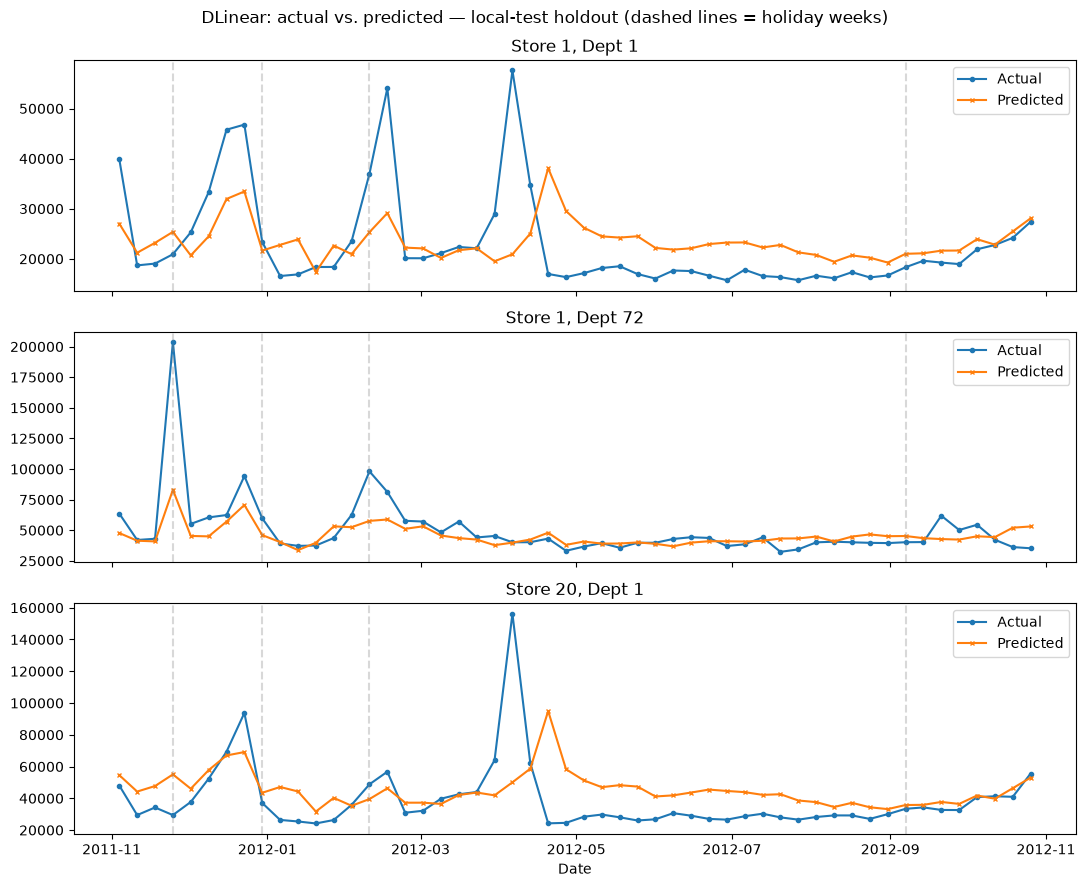

In [18]:
sample_combos = [(1, 1), (1, 72), (20, 1)]

fig, axes = plt.subplots(len(sample_combos), 1, figsize=(11, 9), sharex=True)
for ax, (store, dept) in zip(axes, sample_combos):
    sub = pred_df[(pred_df['Store'] == store) & (pred_df['Dept'] == dept)].sort_values('Date')
    ax.plot(sub['Date'], sub['Actual'], label='Actual', marker='o', markersize=3)
    ax.plot(sub['Date'], sub['Predicted'], label='Predicted', marker='x', markersize=3)
    holiday_dates = sub.loc[sub['IsHoliday'], 'Date']
    for hd in holiday_dates:
        ax.axvline(hd, color='gray', alpha=0.3, linestyle='--')
    ax.set_title(f'Store {store}, Dept {dept}')
    ax.legend()
ax.set_xlabel('Date')
fig.suptitle('DLinear: actual vs. predicted — local-test holdout (dashed lines = holiday weeks)')
plt.tight_layout()
plt.savefig('plots/actual_vs_predicted_timeseries_dlinear.png', dpi=150, bbox_inches='tight')
plt.show()

**Plot 2 — Learned linear weights**, DLinear's analogue of a feature
importance plot: the average magnitude each input position gets from the
`Linear_Seasonal`/`Linear_Trend` layers, averaged over the 13 output steps.
Positions 0-51 are the 52 lookback lags (51 = most recent), positions 52-64
are the 13 future-holiday-flag inputs.

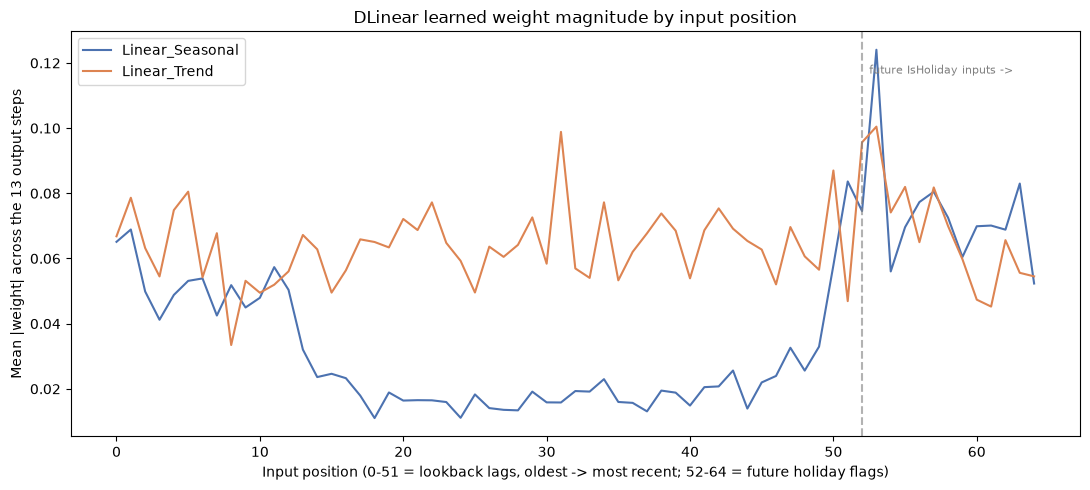

In [19]:
def mean_abs_weight(layer):
    return layer.weight.detach().cpu().abs().mean(dim=0).numpy()  # (in_features,)

seasonal_w = mean_abs_weight(holdout_model.Linear_Seasonal)
trend_w = mean_abs_weight(holdout_model.Linear_Trend)
x = np.arange(len(seasonal_w))
lag_boundary = LOOKBACK  # positions < this are lookback lags; >= this are future-holiday aux

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(x, seasonal_w, label='Linear_Seasonal', color='#4C72B0')
ax.plot(x, trend_w, label='Linear_Trend', color='#DD8452')
ax.axvline(lag_boundary, color='gray', linestyle='--', alpha=0.6)
ax.text(lag_boundary + 0.5, ax.get_ylim()[1] * 0.9, 'future IsHoliday inputs ->', fontsize=8, color='gray')
ax.set_xlabel('Input position (0-51 = lookback lags, oldest -> most recent; 52-64 = future holiday flags)')
ax.set_ylabel('Mean |weight| across the 13 output steps')
ax.set_title('DLinear learned weight magnitude by input position')
ax.legend()
plt.tight_layout()
plt.savefig('plots/feature_importance_tuned_dlinear.png', dpi=150)
plt.show()

**Plot 3 — WMAE by stage**: baseline (untuned, single split) vs. tuned
(single split) vs. final holdout — the DLinear analogue of the tree
notebooks' "WMAE by fold" plot (one split here instead of three folds).

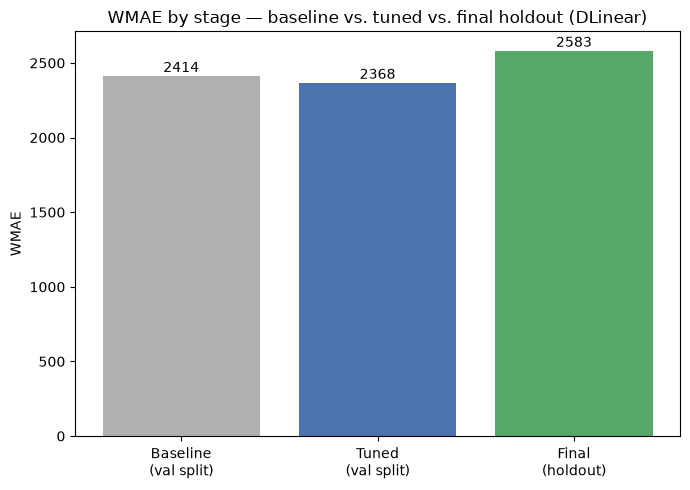

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))
stages = ['Baseline\n(val split)', 'Tuned\n(val split)', 'Final\n(holdout)']
values = [baseline_val_wmae, tuned_val_wmae, holdout_wmae]
colors = ['#B0B0B0', '#4C72B0', '#55A868']
ax.bar(stages, values, color=colors)
for i, v in enumerate(values):
    ax.text(i, v + max(values) * 0.01, f'{v:.0f}', ha='center')
ax.set_ylabel('WMAE')
ax.set_title('WMAE by stage — baseline vs. tuned vs. final holdout (DLinear)')
plt.tight_layout()
plt.savefig('plots/wmae_by_fold_dlinear.png', dpi=150)
plt.show()

**Plot 4 — Residual distribution** on the local-test holdout.

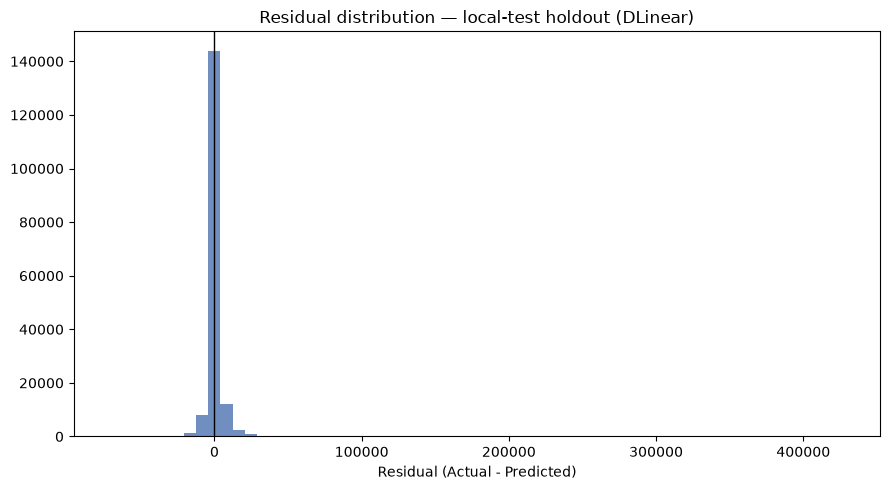

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(pred_df['Residual'], bins=60, color='#4C72B0', alpha=0.8)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Residual (Actual - Predicted)')
ax.set_title('Residual distribution — local-test holdout (DLinear)')
plt.tight_layout()
plt.savefig('plots/residual_distribution_dlinear.png', dpi=150)
plt.show()

**Plot 5 — Actual vs. predicted, holiday vs. non-holiday weeks**

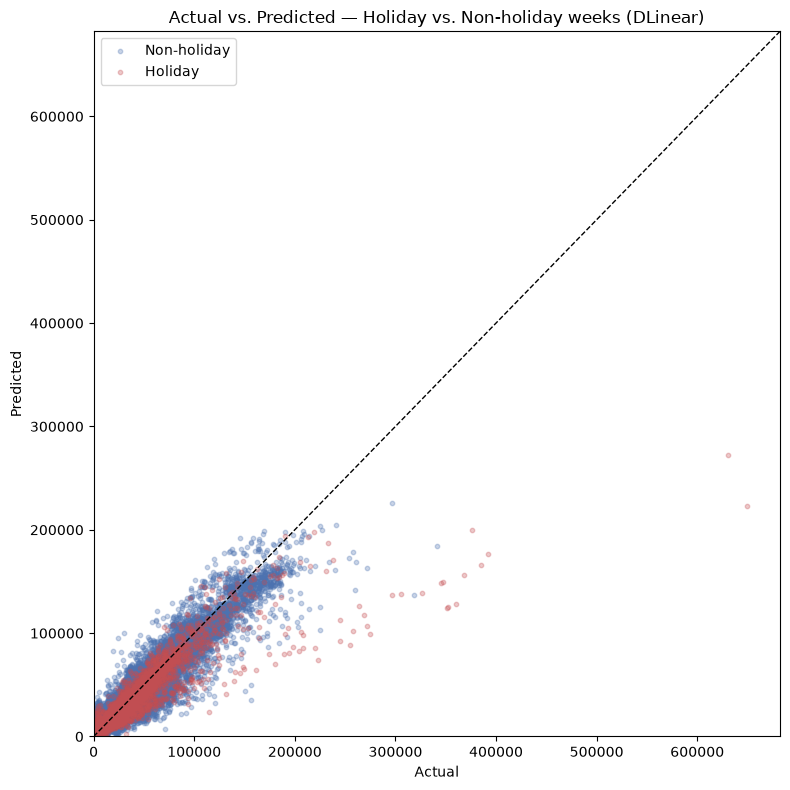

In [22]:
fig, ax = plt.subplots(figsize=(8, 8))
for is_holiday, color, label in [(False, '#4C72B0', 'Non-holiday'), (True, '#C44E52', 'Holiday')]:
    sub = pred_df[pred_df['IsHoliday'] == is_holiday]
    ax.scatter(sub['Actual'], sub['Predicted'], alpha=0.3, s=10, color=color, label=label)
lims = [0, pred_df[['Actual', 'Predicted']].to_numpy().max() * 1.05]
ax.plot(lims, lims, color='black', linewidth=1, linestyle='--')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
ax.set_title('Actual vs. Predicted — Holiday vs. Non-holiday weeks (DLinear)')
ax.legend()
plt.tight_layout()
plt.savefig('plots/actual_vs_predicted_holiday_dlinear.png', dpi=150)
plt.show()

<a id='8'></a>
## 8. Full Pipeline

`utils.dlinear.DLinearForecastPipeline` is the DLinear analogue of the tree
notebooks' `sklearn.pipeline.Pipeline`: `fit()` stores every series' full
history and per-series normalization stats; `predict()` takes bare
`Store/Dept/Date/IsHoliday` rows (e.g. `test.csv` exactly as downloaded) and
handles reindexing, normalization, the recursive block rollout, and
denormalization internally — no manual feature work by the caller.

Fit on **all of `train.csv`** (143 weeks, all 3,331 series — everything
before the real Kaggle `test.csv`, now that tuning/plots are done and
there's no more need to hold anything out), for the same `N_EPOCHS_FINAL`
fixed epochs as Step 7's holdout model (no validation set left to re-tune
against at this stage, same reasoning as before).

In [23]:
full_train_panel = build_full_calendar_panel(train)
full_train_stats = compute_series_stats(full_train_panel)
full_train_arrays = series_arrays_from_panel(full_train_panel)
full_train_dataset = SeriesWindowDataset(full_train_arrays, full_train_stats, LOOKBACK, HORIZON)

print(f'{len(full_train_dataset)} training windows across all of train.csv '
      f'({len(full_train_dataset) / n_series:.0f} per series)')

print(f'Training final model for {N_EPOCHS_FINAL} fixed epochs...')
final_model = train_fixed_epochs(
    full_train_dataset, LOOKBACK, HORIZON, **best_params, n_epochs=N_EPOCHS_FINAL, batch_size=BATCH_SIZE, device=device,
)

full_pipeline = DLinearForecastPipeline(final_model, LOOKBACK, HORIZON, device=device)
full_pipeline.fit(train)
print('DLinearForecastPipeline fit on all of train.csv.')

/Users/r00t/ml-final-project/utils/dlinear.py:117: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  full['IsHoliday'] = full['IsHoliday'].fillna(False)


263149 training windows across all of train.csv (81 per series)
Training final model for 6 fixed epochs...


/Users/r00t/ml-final-project/utils/dlinear.py:117: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  full['IsHoliday'] = full['IsHoliday'].fillna(False)


DLinearForecastPipeline fit on all of train.csv.


**Confirm it truly takes raw input**: predict on bare rows straight from
`test.csv` — unmerged, no history/lag/rolling computed by the caller.

In [24]:
raw_sample = test.head(5)
print('Raw input columns (exactly test.csv, nothing pre-computed):', raw_sample.columns.tolist())

raw_preds = full_pipeline.predict(raw_sample[['Store', 'Dept', 'Date', 'IsHoliday']])
print()
print('Predictions:', raw_preds)

Raw input columns (exactly test.csv, nothing pre-computed): ['Store', 'Dept', 'Date', 'IsHoliday']

Predictions: [30016.24300328 22036.92924178 21089.60177332 21583.52505418
 21989.98932352]


**Save to MLflow (DagsHub model registry)** inside `DLinear_Final_Fit`.
`mlflow.pyfunc` (not `mlflow.pytorch`) since the saved artifact needs to be
the whole raw-input-to-prediction path (reindexing, normalization,
recursive rollout, denormalization), not just the bare `nn.Module` —
same reasoning as the tree notebooks' `serialization_format='cloudpickle'`
choice for their custom transformer classes: this wrapper is arbitrary
Python holding a `torch.nn.Module` plus per-series history/stats, not
something a stock flavor understands, so it's saved as a `PythonModel`
(cloudpickled by `mlflow.pyfunc` automatically).

In [25]:
from mlflow.models import infer_signature


class DLinearPyfuncWrapper(mlflow.pyfunc.PythonModel):
    def __init__(self, pipeline):
        self.pipeline = pipeline

    def predict(self, context, model_input, params=None):
        return self.pipeline.predict(model_input)


signature = infer_signature(raw_sample[['Store', 'Dept', 'Date', 'IsHoliday']], raw_preds)

with mlflow.start_run(run_name='DLinear_Final_Fit'):
    mlflow.log_params(best_params)
    mlflow.log_param('lookback', LOOKBACK)
    mlflow.log_param('horizon', HORIZON)
    mlflow.log_param('n_epochs_final', N_EPOCHS_FINAL)
    mlflow.log_metric('local_test_holdout_wmae', holdout_wmae)
    mlflow.log_metric('n_series_trained', n_series)

    mlflow.pyfunc.log_model(
        artifact_path='model',
        python_model=DLinearPyfuncWrapper(full_pipeline),
        signature=signature,
        input_example=raw_sample[['Store', 'Dept', 'Date', 'IsHoliday']],
    )

print('DLinear_Final_Fit run logged, pipeline saved to MLflow model registry.')

/Users/r00t/ml-final-project/.venv-dlinear/lib/python3.11/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
/Users/r00t/ml-final-project/.venv-dlinear/lib/python3.11/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `H

🏃 View run DLinear_Final_Fit at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/3/runs/69669dee8c954065aef67466dd4273d1
🧪 View experiment at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/3
DLinear_Final_Fit run logged, pipeline saved to MLflow model registry.


**Also save locally** under `models/` — the fitted pipeline (model +
history + stats) via `torch.save`, since it holds a `torch.nn.Module` and
`torch.save` is the more standard/robust choice for that over generic
pickling.

In [26]:
import os

os.makedirs('models', exist_ok=True)
torch.save({
    'model_state_dict': full_pipeline.model.state_dict(),
    'lookback': LOOKBACK,
    'horizon': HORIZON,
    'kernel_size': best_params['kernel_size'],
    'history_': full_pipeline.history_,
    'stats_': full_pipeline.stats_,
    'last_date_': full_pipeline.last_date_,
}, 'models/dlinear_pipeline.pt')
print('Saved to models/dlinear_pipeline.pt')

Saved to models/dlinear_pipeline.pt


In [27]:
checkpoint = torch.load('models/dlinear_pipeline.pt', weights_only=False)

reloaded_model = DLinear(
    lookback=checkpoint['lookback'], horizon=checkpoint['horizon'],
    kernel_size=checkpoint['kernel_size'], n_aux_channels=checkpoint['horizon'],
).to(device)
reloaded_model.load_state_dict(checkpoint['model_state_dict'])

reloaded_pipeline = DLinearForecastPipeline(reloaded_model, checkpoint['lookback'], checkpoint['horizon'], device=device)
reloaded_pipeline.history_ = checkpoint['history_']
reloaded_pipeline.stats_ = checkpoint['stats_']
reloaded_pipeline.last_date_ = checkpoint['last_date_']

reloaded_preds = reloaded_pipeline.predict(raw_sample[['Store', 'Dept', 'Date', 'IsHoliday']])
print('Reloaded-pipeline predictions match:', np.allclose(reloaded_preds, raw_preds))

Reloaded-pipeline predictions match: True
